In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf # Yahoo Finance API

# Machine Learning imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# downloading last 5 years of APPlE stocks data from Yahoo Finance
stock_data = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01"
)

stock_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861862,72.466345,71.642704,72.211064,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


In [17]:
stock_data.to_csv("./data/apple_stock_data.csv", index=True)
print("Data saved to apple_stock_data.csv")

Data saved to apple_stock_data.csv


In [18]:
print("Shape of Dataset:")
print(stock_data.shape)

print("\nData Types:")
print(stock_data.dtypes)

print("\nMissing Values:")
print(stock_data.isnull().sum())

Shape of Dataset:
(1258, 5)

Data Types:
Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

Missing Values:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


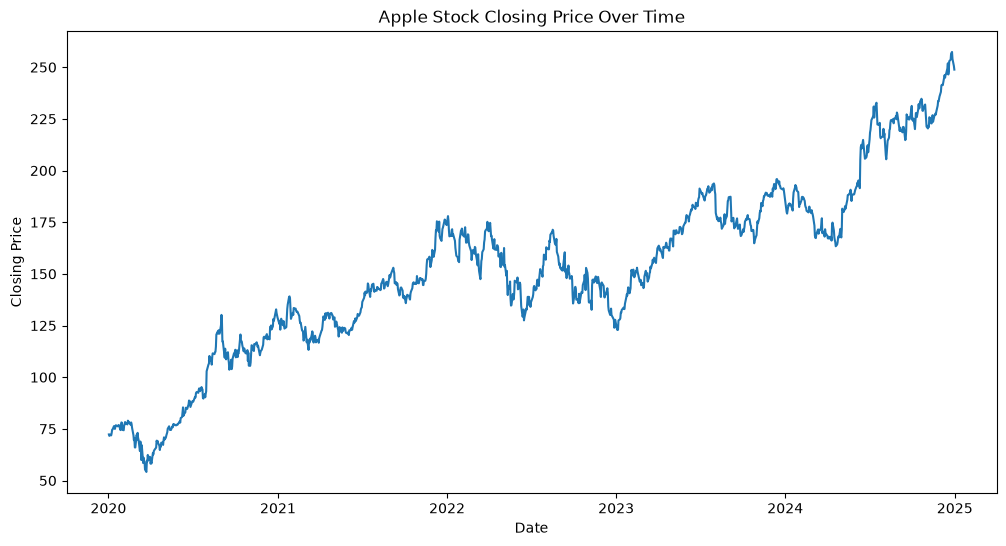

In [23]:
# Visualize closing price trends over time

plt.figure(figsize=(12,6))

plt.plot(stock_data['Close'])

plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

In [25]:
"""
Our goal is to predicy the future stock price of Apple Inc.
using historical stock data. 

Like "Tomorrow's Closing Price"
"""

# creating next day closing column
stock_data['Next_Close'] = stock_data['Close'].shift(-1)

stock_data.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400,71.630630
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,72.201416
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,71.861862
2020-01-07,71.861862,72.466345,71.642704,72.211064,108872000,73.017845
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200,74.568794


In [29]:
# dropping missing values
stock_data = stock_data.dropna()
print(stock_data.shape)

(1257, 6)


In [33]:
# Select Features and Target
X = stock_data[['Open', 'High', 'Low', 'Volume']]
y = stock_data['Next_Close']

In [34]:
# Splitting data in 80-20 ratio for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
# Creating Models

model = LinearRegression()

model.fit(X_train, y_train) # training model

print("Model training completed.")

Model training completed.


In [37]:
# Generate predictions

y_pred = model.predict(X_test)

print(y_pred[:5])

[143.27064412  77.46250726  60.00648036  58.46756478 167.43041365]


In [38]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)  

Mean Absolute Error: 2.236982697650463
Root Mean Squared Error: 3.1781034848208694
R2 Score: 0.9942324895799421


In [ ]:
"""
This table will show the actual closing price vs predicted closing price for the test set.
"""
# Actual vs Predicted Comparison 
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred 
})

comparison.head(10) # can show more rows by replacing the number inside head()

,Actual,Predicted
0,143.425125,143.270644
1,76.959602,77.462507
2,59.546997,60.006480
3,58.277233,58.467565
4,167.985001,167.430414
5,151.420319,152.109811
6,182.321198,183.566900
7,154.320862,157.722020
8,222.806488,222.840577
9,182.034103,182.845737


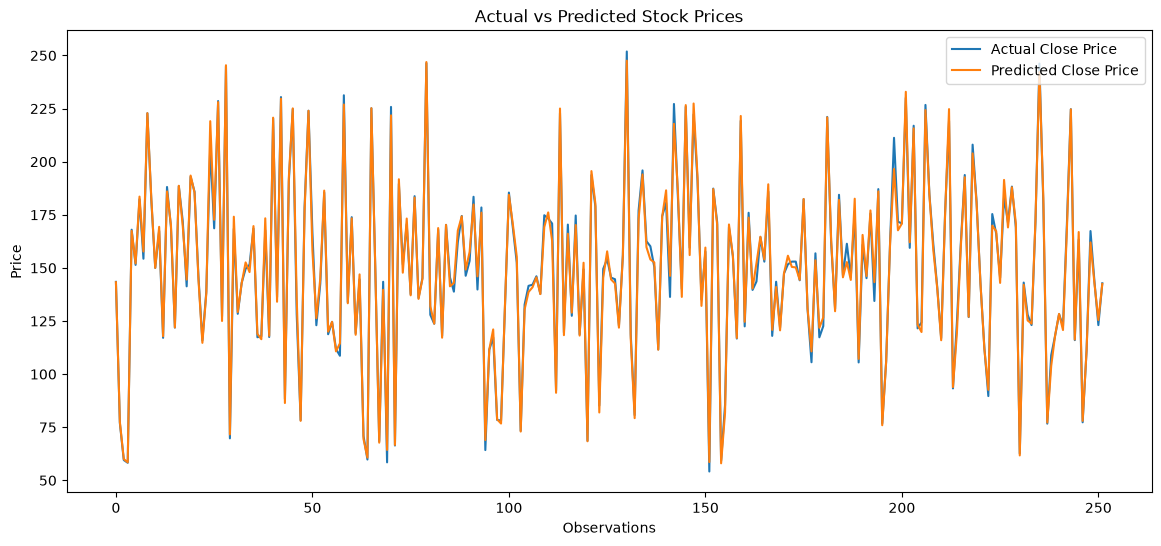

In [48]:
"""
Plotting for the visual representation of 
the actual vs predicted closing prices for 
the test set.
"""

# Plot Actual vs Predicted Closing Prices

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual Close Price'
)

plt.plot(
    y_pred,
    label='Predicted Close Price'
)

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Observations")
plt.ylabel("Price")

plt.legend()

plt.show()

In [55]:
"""
We have here an optional improvement option to imporve model
using Random Forest Regressor. This is an ensemble learning method that can capture non linear relationships in the data, which might improve the prediction accuracy compared to linear regression.
"""

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# Evaluate the Random Forest Model 

mae = mean_absolute_error(y_test, rf_predictions)

rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

# now it time to save the model's results
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results_df.to_csv(
    "./outputs/stock_price_results.csv",
    index=False
)

print("\nResults saved succesfully.")

Random Forest Results
MAE : 2.3751298362489726
RMSE: 3.2205581773295813
R²  : 0.9940773698052119

Results saved succesfully.


# 📈 Predict Future Stock Prices (Short-Term)

## Project Overview

Stock prices fluctuate daily due to market conditions, investor sentiment, company performance, and economic events. Analyzing historical stock data can help identify patterns that may be useful for forecasting future prices.

In this project, historical stock market data is collected from **Yahoo Finance** using the **yfinance** Python library. A machine learning regression model is then trained to predict the **next day's closing stock price** based on trading information from the current day.

The project demonstrates the complete machine learning workflow, including:

- Data collection using an API
- Data exploration and preprocessing
- Feature engineering
- Regression model training
- Model evaluation
- Data visualization

This project is implemented in **Python** using **Jupyter Notebook**.

---

# 🎯 Objective

The primary objective of this project is to predict the **next day's closing stock price** using historical stock market data.

The model uses the following features from the current trading day:

- Open Price
- High Price
- Low Price
- Volume

to predict:

- Next Day Closing Price

This task is a **supervised machine learning regression problem** because the target variable (next day's closing price) is a continuous numerical value.

---

# 📊 Dataset

## Dataset Source

The dataset is obtained directly from **Yahoo Finance** using the `yfinance` Python library.

### Example Stock Used

For this project, Apple Inc. stock data is used:

```python
ticker = "AAPL"
```

Other stocks can also be used:

- Tesla (TSLA)
- Microsoft (MSFT)
- Amazon (AMZN)
- Google (GOOGL)

---

## Dataset Features

The downloaded dataset contains the following columns:

| Feature | Description |
|----------|-------------|
| Open | Stock price at market opening |
| High | Highest stock price during the day |
| Low | Lowest stock price during the day |
| Close | Stock price at market close |
| Adj Close | Adjusted closing price |
| Volume | Number of shares traded |

---

## Target Variable

To predict the future stock price, a new column called **Next_Close** is created.

```python
stock_data["Next_Close"] = stock_data["Close"].shift(-1)
```

This means:

| Current Day Close | Next_Close |
|------------------|------------|
| 180.50 | 182.10 |
| 182.10 | 181.40 |
| 181.40 | 183.25 |

The model learns to predict tomorrow's closing price based on today's market information.

---
### Libraries

| Library | Purpose |
|----------|----------|
| pandas | Data manipulation and analysis |
| numpy | Numerical computations |
| matplotlib | Data visualization |
| yfinance | Download stock market data |
| scikit-learn | Machine learning models and evaluation |

---

# 📂 Project Structure

```text
predict_future_stock_task2/
│
├── data/
│   └── apple_stock_data.csv
│
├── stock_price_prediction.ipynb
│
├── outputs/
│   ├── stock_price_results.csv
│
├── models/
|
```

---

## Install Required Libraries

```bash
pip install pandas numpy matplotlib scikit-learn yfinance jupyter
```

---

# Project Workflow

The project follows the standard machine learning lifecycle.

---

## 1. Data Collection

Historical stock data is downloaded from Yahoo Finance using the `yfinance` library.

Example:

```python
import yfinance as yf

stock_data = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01"
)
```

The dataset contains several years of stock trading information.

---

## 2. Data Exploration

The dataset is examined to understand:

- Number of records
- Number of features
- Data types
- Missing values
- General structure

Example:

```python
stock_data.info()
stock_data.describe()
stock_data.isnull().sum()
```

---

## 3. Data Visualization

Before building the model, the stock's closing price trend is visualized.

This helps understand:

- Long-term trends
- Market volatility
- Price movement patterns

Example:

```python
plt.plot(stock_data["Close"])
plt.show()
```

---

## 4. Feature Engineering

To predict future prices, the target variable is created by shifting the Close column one day forward.

```python
stock_data["Next_Close"] = stock_data["Close"].shift(-1)
```

The last row is removed because it has no future closing price available.

```python
stock_data.dropna(inplace=True)
```

---

## 5. Feature Selection

The following features are selected as input variables:

```python
X = stock_data[
    ["Open", "High", "Low", "Volume"]
]
```

Target variable:

```python
y = stock_data["Next_Close"]
```

---

## 6. Data Splitting

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

Example:

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

---

## 7. Model Training

### Linear Regression

Linear Regression is used as the primary machine learning model.

It attempts to learn the relationship between:

- Open
- High
- Low
- Volume

and the target:

- Next_Close

Example:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
```

---

## 8. Making Predictions

After training, predictions are generated using unseen test data.

Example:

```python
y_pred = model.predict(X_test)
```

---

## 9. Model Evaluation

Model performance is measured using the following evaluation metrics:

### Mean Absolute Error (MAE)

Measures the average prediction error.

```python
mean_absolute_error(y_test, y_pred)
```

---

### Root Mean Squared Error (RMSE)

Measures prediction accuracy and penalizes larger errors.

```python
np.sqrt(mean_squared_error(y_test, y_pred))
```

---

### R² Score

Indicates how well the model explains stock price variation.

```python
r2_score(y_test, y_pred)
```

---

## 10. Results Visualization

A comparison plot is created to visualize:

- Actual Closing Prices
- Predicted Closing Prices

Example:

```python
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()
```

This visualization helps determine how closely the model follows actual market behavior.

---

# 🤖 Machine Learning Model

## Linear Regression

Linear Regression is chosen because:

- Easy to understand
- Fast to train
- Effective baseline model
- Suitable for numerical prediction tasks

General equation:

```text
y = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ
```

Where:

- y = Predicted value
- x = Input features
- b = Learned coefficients

---

## Optional Model: Random Forest Regressor

To improve performance, a Random Forest Regressor can also be used.

Advantages:

- Captures nonlinear relationships
- More robust than Linear Regression
- Handles complex patterns in financial data

Example:

```python
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
```

---

# 📈 Expected Output

The project generates:

### 1. Historical Stock Price Trend

A line chart showing stock closing prices over time.

### 2. Actual vs Predicted Plot

A graph comparing:

- Actual next-day closing prices
- Predicted next-day closing prices

### 3. Evaluation Metrics

Example:

```text
Mean Absolute Error (MAE): 2.35

Root Mean Squared Error (RMSE): 3.10

R² Score: 0.94
```

---

# 📋 Results Interpretation

### MAE

A lower MAE indicates that predictions are closer to actual stock prices.

### RMSE

A lower RMSE indicates better predictive performance.

### R² Score

R² values range from 0 to 1.

Interpretation:

| R² Score | Meaning |
|-----------|----------|
| 0.90+ | Excellent fit |
| 0.70–0.89 | Good fit |
| 0.50–0.69 | Moderate fit |
| Below 0.50 | Weak fit |

---

# 🧠 Skills Demonstrated

This project demonstrates practical experience in:

### Data Collection

- Using APIs to retrieve financial data

### Data Preprocessing

- Handling missing values
- Preparing machine learning datasets

### Feature Engineering

- Creating future prediction targets

### Machine Learning

- Regression modeling
- Model training and testing

### Evaluation

- Performance measurement using standard metrics

### Visualization

- Trend analysis
- Prediction comparison plots

---

# 🚀 Future Improvements

Several enhancements could improve prediction accuracy:

### Technical Indicators

Add:

- Moving Averages
- RSI (Relative Strength Index)
- MACD
- Bollinger Bands

### Advanced Machine Learning Models

Explore:

- XGBoost
- LightGBM
- CatBoost

### Deep Learning Models

Use:

- LSTM Networks
- GRU Networks
- Transformer-based Time Series Models

### Time-Series Validation

Replace random train-test split with chronological splitting for more realistic forecasting.

### Real-Time Prediction Dashboard

Deploy using:

- Streamlit
- Flask
- Dash

---

# 🎓 Learning Outcomes

After completing this project, you will understand:

- How to retrieve stock market data using APIs
- How to work with time-series datasets
- How to engineer features for forecasting
- How regression models make predictions
- How to evaluate model performance
- How to visualize and interpret results
- How to build an end-to-end machine learning project

---

# 🏁 Conclusion

This project successfully demonstrates how machine learning can be applied to financial data for short-term stock price prediction. Historical stock data from Yahoo Finance was collected, processed, and used to train a regression model capable of predicting the next day's closing price.

The project provides hands-on experience with data acquisition, preprocessing, machine learning, evaluation, and visualization, making it an excellent introduction to stock market forecasting and predictive analytics.